In [ ]:
   !pip -q install -U \
    langchain-google-genai \
    langchain-core \
    pydantic \
    pillow \
    pytesseract

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 9.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [ ]:
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import os
import json
import base64

from getpass import getpass
from PIL import Image
import pytesseract

from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass(
        "Enter your Gemini API key: "
    )
#AQ.Ab8RN6LCaVXPqsecx6yBSHZnoVn4fKZHdDkX-F7MlIJnVT6tzQ
print("Gemini API key loaded.")


Enter your Gemini API key: ··········
Gemini API key loaded.


In [ ]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

print("Gemini model ready.")

Gemini model ready.


In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded file:", image_path)

Saving image2.jpg to image2.jpg
Uploaded file: image2.jpg


Image size: (1809, 2560)


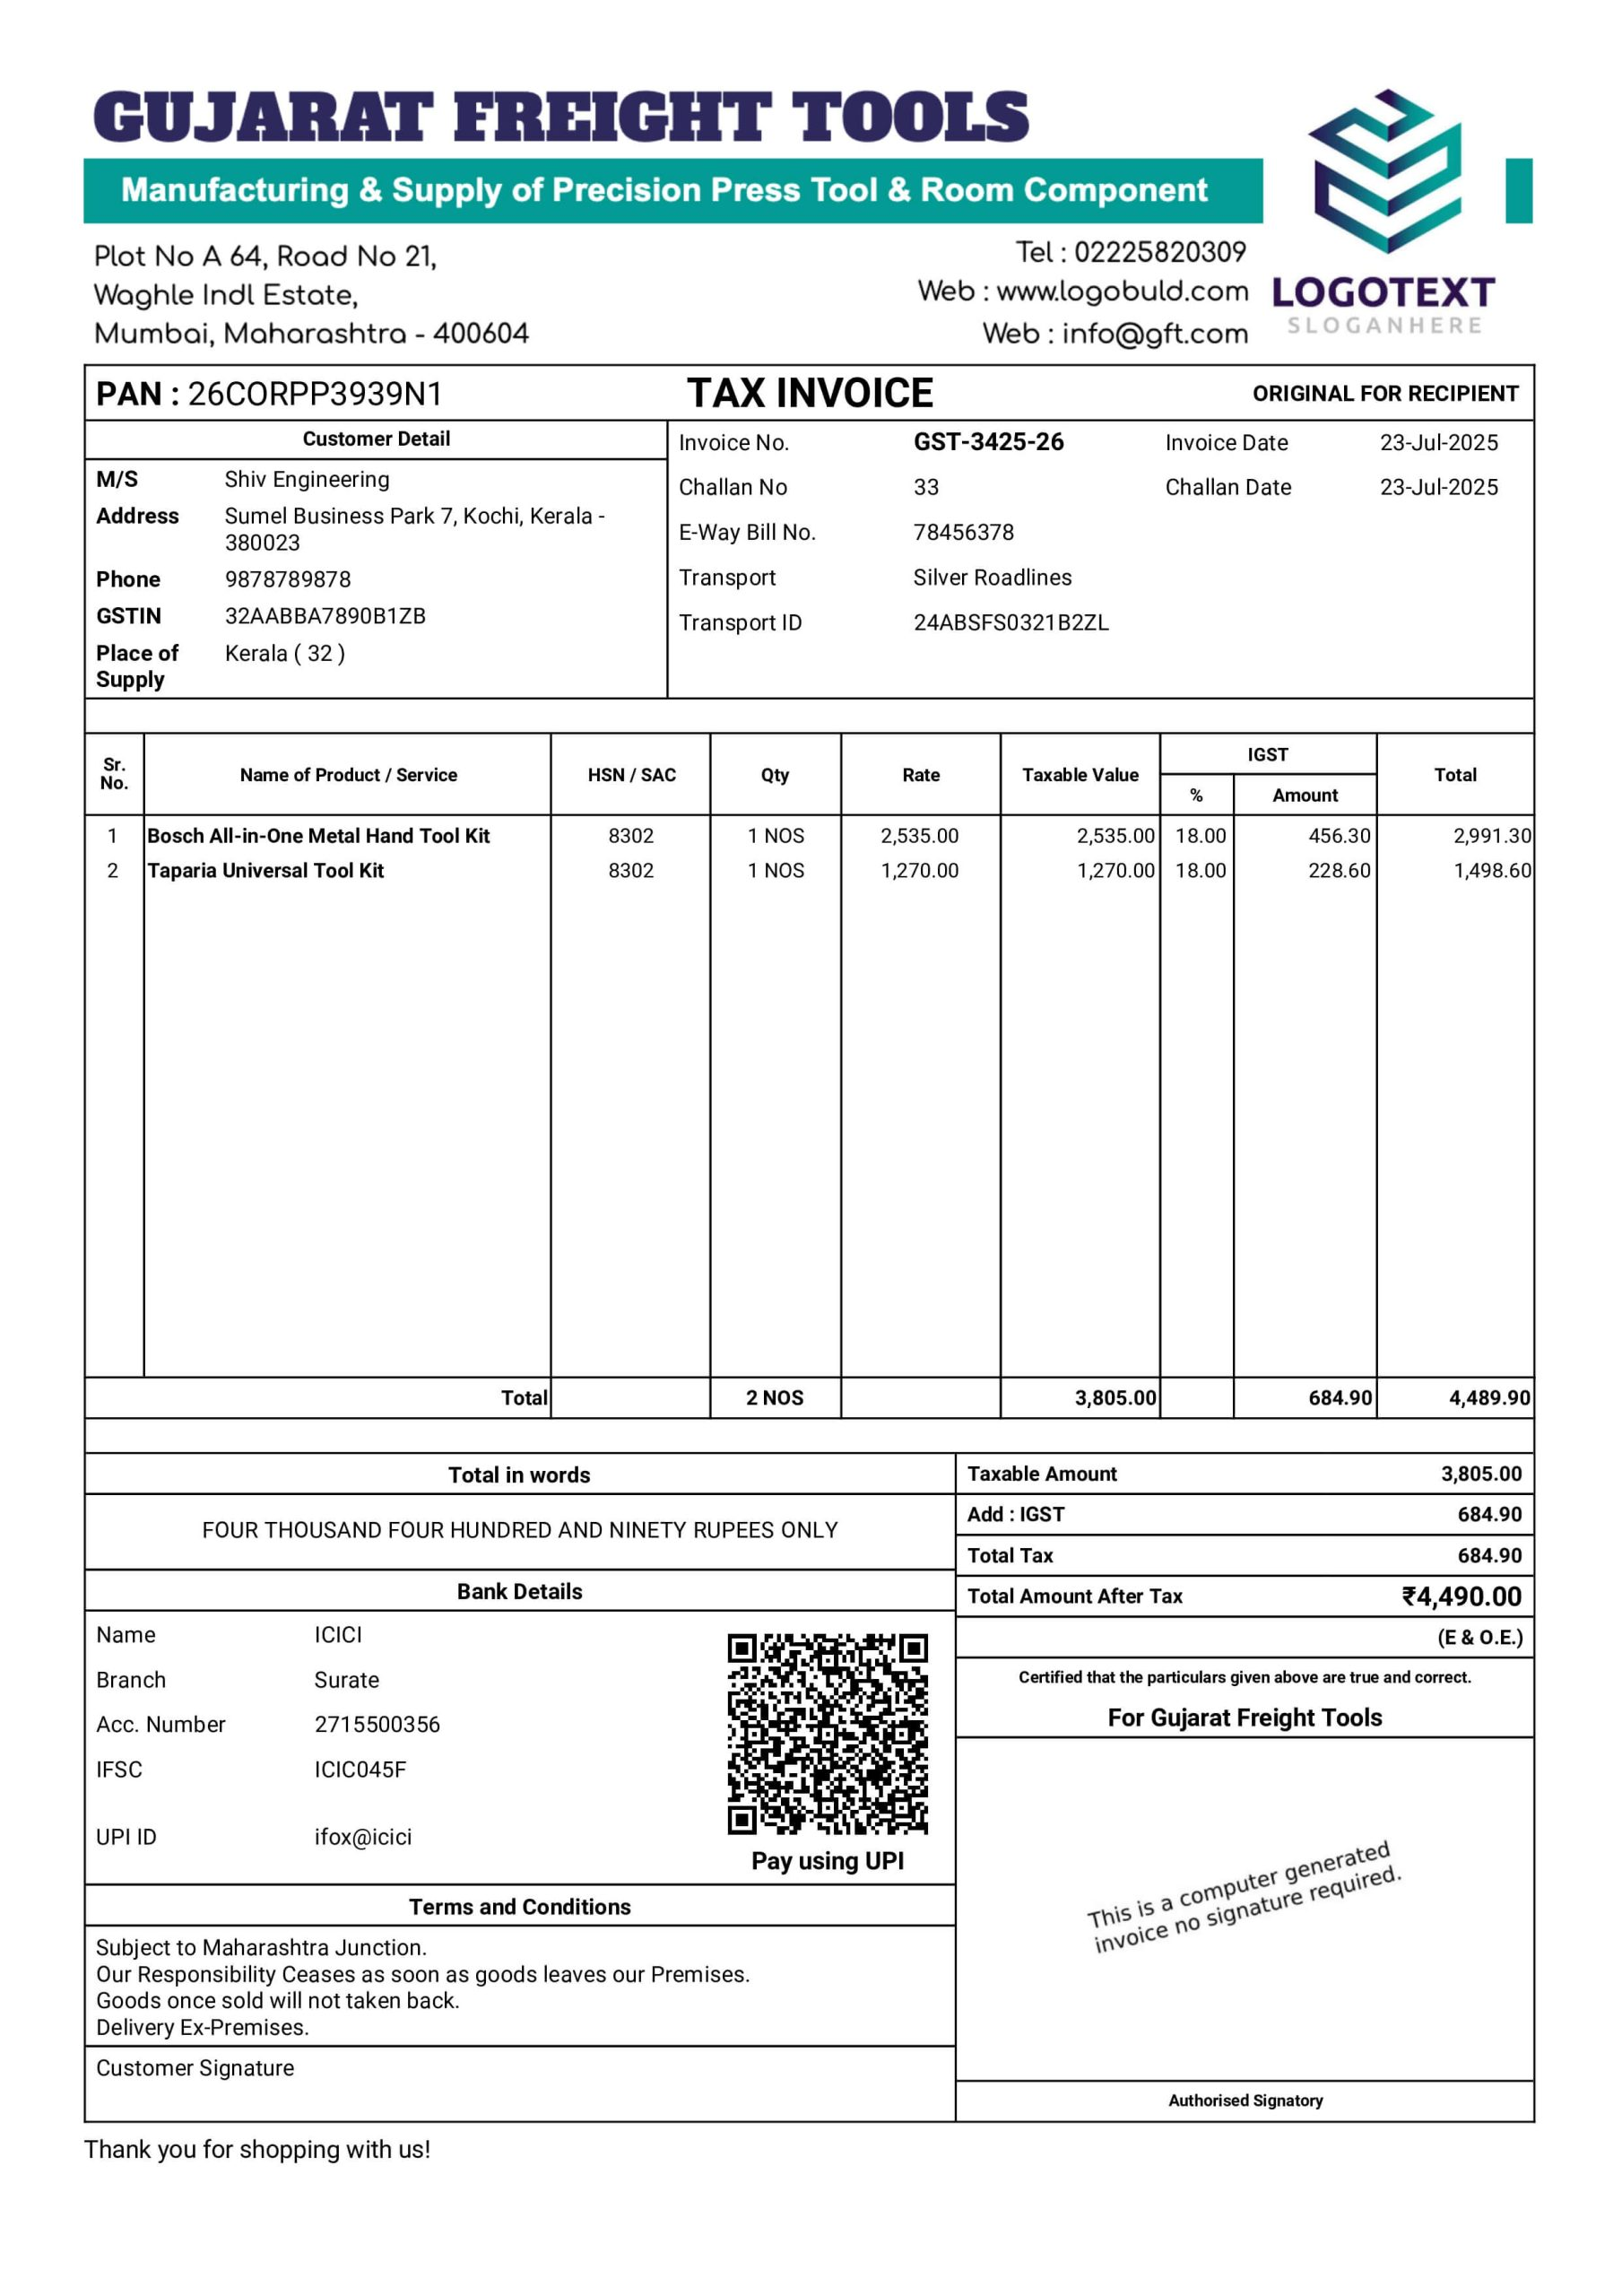

In [ ]:
image = Image.open(image_path)

print("Image size:", image.size)
display(image)

In [ ]:
with open(image_path, "rb") as f:
    image_bytes = f.read()

image_base64 = base64.b64encode(image_bytes).decode("utf-8")

print("Image converted to Base64.")

Image converted to Base64.


In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Describe everything important you can see in this invoice."
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Here is a detailed breakdown of all the important information visible on this tax invoice:\n\n---\n\n### **1. Header & Seller (Vendor) Information**\n* **Company Name:** GUJARAT FREIGHT TOOLS\n* **Business Type:** Manufacturing & Supply of Precision Press Tool & Room Component\n* **Address:** Plot No A 64, Road No 21, Wagle Indl Estate, Mumbai, Maharashtra - 400604\n* **Contact Details:** \n  * **Phone:** 02225820309\n  * **Website / Email:** www.logobuld.com / info@gft.com\n* **Seller PAN:** 26CORPP3939N1\n\n---\n\n### **2. Invoice Meta & Transport Details**\n* **Document Type:** TAX INVOICE (Original for Recipient)\n* **Invoice Number:** GST-3425-26\n* **Invoice Date:** 23-Jul-2025\n* **Challan Number:** 33\n* **Challan Date:** 23-Jul-2025\n* **E-Way Bill No.:** 78456378\n* **Transport Name:** Silver Roadlines\n* **Transport ID:** 24ABSFS0321B2ZL\n\n---\n\n### **3. Buyer / Customer Details**\n* **Customer Name:** Shiv Engineering\n* **Address:** Sumel Busin

In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "What is the vendor name?"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the invoice, the vendor name is **Gujarat Freight Tools**.', 'extras': {'signature': 'Ev8ECvwEAWkUfRNga0wwvY8z8JQ6eiycLlIbzHZNr8gzpnQvpP6i73kDw7GqUUCVkMHZN4kQJmdDrMDz+sol+xdbbjBucIV6/pRke8IS/lL9OWrUCYDCtlkEhfMWwxPtlozvD4JfYKWBlybAuzXs1YBbwe9XijqXMGcq6v9I9MuFRYkB4iCwUmYZH9kk7QA1h7YkBs2gGPy9OIbYTP6J4tLyYmYAt7Zh7Phyai8pjmbzk9kDz+hoN0yDmruzO9j08B0cElF/NmO6JA9CEDjNNk4+XlZvHN4xT0IYdTeonAqHim7AhT7mbOa2IeurkoFG70kiz+l+Xtx4u8GVCJ+xX3DWXTjx4C1QulbtN0jYHGdGDKTAzcnXiDHoq2KhFK4pv6J8DIu9xpAvLlcc0mdzAfuDSxFK3gAgRfNLkJdVlzTsJrE3LcGtjqK3nUTV6sE8Y7YUJ6bLBQQ4KPamxmF54fAw+iR10opQzqkNrVNtCvQtETbk/GrwBIlRG4VQ3Uaer9MDchvfwHed8g2OKHg6gb4UQTkpJ0ldbehmNpWA7z5ZiGgLu8c8UNANwUNaUem4St6CRCl8Id3Bv7/3otkRxCRNFwh3KtnpK4U2+CllLGG77Mi4GCIizuq3f27DNrmBJSBeh2qIrCIsi/jT42ozrNAxGmVo0TKlQbsec6eZ4qhncfG3+3u8FOHTgJsW2XxUJHsxWE4wMfZcazNf8f0FwQBJrl2MJPpMimFefnrglIRitj5qKdQX5r5DBgYXqtQXUOa4SyaJHbUQ55++jO2UesUc/EEq5y3A2UiVGeLZ64kf4f1/xCDgaRbxLlZFdXd9vjn3QIJtEvOuYMR63tIpEx/H'}}]


In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "What is the invoice number?"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'The invoice number is **GST-3425-26**.', 'extras': {'signature': 'EuACCt0CAWkUfROjiy2KkuV8OSsgDRDwG5awDLQQMaONLEQDPN2x9CS4zAUxYWKFUREqSCynVdiqPJS+VnoPYsKNPXtb9mLzbIDll4gNGdTDC+2uuZtn4APP1j3GEL1V89qm6zGVtmfBlEjXR2a6t9L/bgtegH+4EmeYzlf0BVtgQlNAHp6aJIVuXh3mpcS21yeeLtr97X9giWIu9uNx00sM6cuCRlLS3NFVf7dttZgDuF94U5MqnaECZS6i3Mfp33gxqDI3cMf5MaPbgoB20rzfqAmBA8qOCj3UYkkYiP90cGac8y/lbA46jeO/Vl6NKNgiHAPaC6cISNs3cmOW0uHzSf1gENGWoBz5dMUvLRmDXXVH6p/o501zW9MAGwLIetmsPPV75eTOTFsf1Me0J3FfYCspgqT6MSOWJTSRLzzkrsl1vd/8Ptif2sWoj5ADzkHWFGMQSgeBD68PF5KlFcwdnA=='}}]


In [ ]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "What is the final invoice total?"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'The final invoice total is **₹4,490.00** (Four Thousand Four Hundred and Ninety Rupees Only).', 'extras': {'signature': 'ErcHCrQHAWkUfRMma5VER3KcaaIGmMkWvhZgkVF/4xUHequa2pZSEKBzqTD03fGljtSMVjdRJF6Of9UgMHP8R2ev+dgl2eLV9hLH3HA9RQupO4x/l6JAOqoHPzQd3ea+cL3Cj/fgasgF4kra8edBq5gNWDMq6yRr6VUjJMAKM0Vcthe51mFTFSbKHmPUyUj3gLYU8ldGkyjWhMjlx4l583BicSf0MUxI56GH7v5FpNhRaC6o0BdnwrtBwPocB1RtiHxKEivXHFtwPcvexm71L9hhjEkEPYMBDkKu8LCxODNfDL/kSRIrJaBn8NBHdDYmVQ7+RD3ZBIPsS7el3odSdUbDyC9OlA6Q7SDcnPeJLjw+p9G8JrbKLkx9BAzbvROWyu7blydTJTlBvaJzVvVe46T0w7eU0PFhn+NGf23Gj8SzL/v5Hqnicgo3xAbLdlRqHTG81EU91AJc24unYzqdEnbM0PaYebjkHkH9J4adg44Zm84yZxipiQ/uF1Y9FNJr3q0I7VU1xizisLkywon8YHFRgy9m2i7WaYCZNDJyOAoE9hRCD5VfdabOqR1lKaOdt9DAgFrXSZy93D+dR7HPgGNvPL5Qw5Y4N0UoOJUTWBC/NEMRptla/UDgFEXjuINi7xFxwNj9ZBnY12LMUC5d0iG1N33oa5Gsk25h/ZD96WsLxmM6P89aIopjyYjHCZbTU2XpGOrerC4fzLNKLwrKY9IPk5XjWjTIYsZpI/mzBEWivIPhv1lmaN+hviwqAwDwW6eH7DKSIWn4LEDTfgcquypYAORxBwdV7afweyYNsOwMnqCa8nsbR8f+Yzfo3l1U/RScmOU7uhXcM6MrVZFw

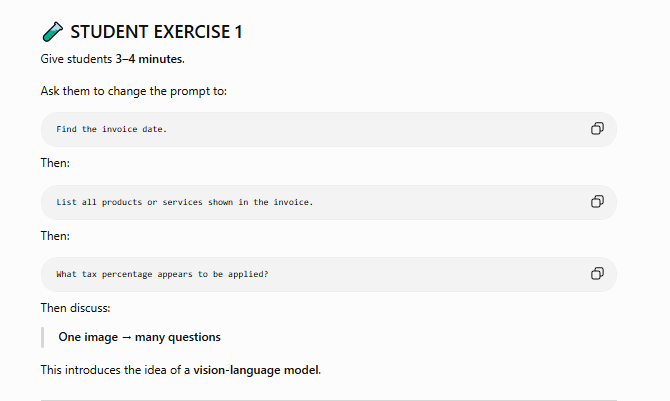

In [ ]:
bad_prompt = """
Extract information from this invoice.
"""

message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": bad_prompt
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Here is the extracted information from the invoice:\n\n---\n\n### **1. Seller Information**\n* **Company Name:** GUJARAT FREIGHT TOOLS\n* **Address:** Plot No A 64, Road No 21, Wagle Indl Estate, Mumbai, Maharashtra - 400604\n* **Phone:** 02225820309\n* **Email:** info@gft.com\n* **Website:** www.logobuld.com\n* **PAN:** 26CORPP3939N1\n\n---\n\n### **2. Invoice Details**\n* **Invoice Number:** GST-3425-26\n* **Invoice Date:** 23-Jul-2025\n* **Challan Number:** 33\n* **Challan Date:** 23-Jul-2025\n* **E-Way Bill No.:** 78456378\n* **Transport:** Silver Roadlines\n* **Transport ID:** 24ABSFS0321B2ZL\n\n---\n\n### **3. Customer / Bill To Details**\n* **Name:** Shiv Engineering\n* **Address:** Sumel Business Park 7, Kochi, Kerala - 380023\n* **Phone:** 9878789878\n* **GSTIN:** 32AABBA7890B1ZB\n* **Place of Supply:** Kerala (32)\n\n---\n\n### **4. Line Items**\n\n| Sr. No. | Product / Service Description | HSN / SAC | Qty | Rate (₹) | Taxable Value (₹) | IGST Rate

In [ ]:
good_prompt = """
You are an invoice extraction assistant.

Analyze the invoice carefully.

Extract:

1. Vendor name
2. Invoice number
3. Invoice date
4. Subtotal
5. Tax
6. Discount
7. Final total

Rules:
- Do not invent information.
- If a value is not visible, say "Not available".
- Preserve numbers accurately.
- Clearly separate each field.
"""

message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": good_prompt
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_base64}"
            }
        }
    ]
)

response = llm.invoke([message])

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the invoice provided, here are the extracted details:\n\n1. **Vendor Name:** GUJARAT FREIGHT TOOLS\n2. **Invoice Number:** GST-3425-26\n3. **Invoice Date:** 23-Jul-2025\n4. **Subtotal:** 3,805.00\n5. **Tax:** 684.90\n6. **Discount:** Not available\n7. **Final Total:** ₹4,490.00', 'extras': {'signature': 'EtMMCtAMAWkUfRO90srmQyEY/q3iAVD59taBkY1lrf2mfiis+x8KJMHGIBkzEuEBhwVXAa+wlG3D0hvjKQKLl58GdLWEhE4n4s7L1BxakTxF1XLMMlYCHf4hhoyATekl6lNwvax3Jn5Z2WkmXhGxkMnNw0YAWFui2cr71UsKaXpzJvkbqk0mUXXvMmf0zhuU8woToMlqhZQTZpTMYBaW69s61wi5fadMR0CgffvJd9zwMbzk4tHk1uNZfWg8gLVig2M09hCbe9C9dNX9LqRu5gJZ5lS4ZV+MjlfFlSiRBJiD4SFy5BIKzcPjxmea3XR0K4dX9j4D/H4jjMNWvbYQM1gdvoGy9+UpgugL3Hd43q8JbTS1ZICusKGuxTuhS1xVcA8c76uNJV9fFIrDW+4bG87BMy7WExASnbaq13cwDW7z5hduwuO7seI0RwzOXyuu81yB6P57WHhCunmOr5mn8qJg697Rcv7kGlaqnq59NRfxS14Ut+MmJWULk/WAfVGpGFEWlgp+yfQ0a2TdV21RW9UMCOudCaDiY8xy5/sGqIUpU+yWU+Fi4RxmPNz3Wl/DP4XGeJyz78vlmFCUOI6r1dxbb/unSHHpbpvZlQ/e6iAB1kt0UFfVSuGuLRRVAhquy2VG4eMlUtuBQppeny

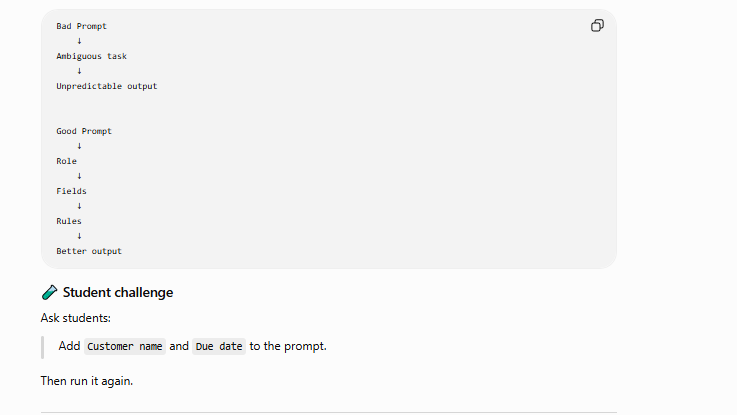

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

Saving image2.jpg to image2 (1).jpg
Uploaded: image2 (1).jpg


Image size: (1809, 2560)
Image mode: RGB


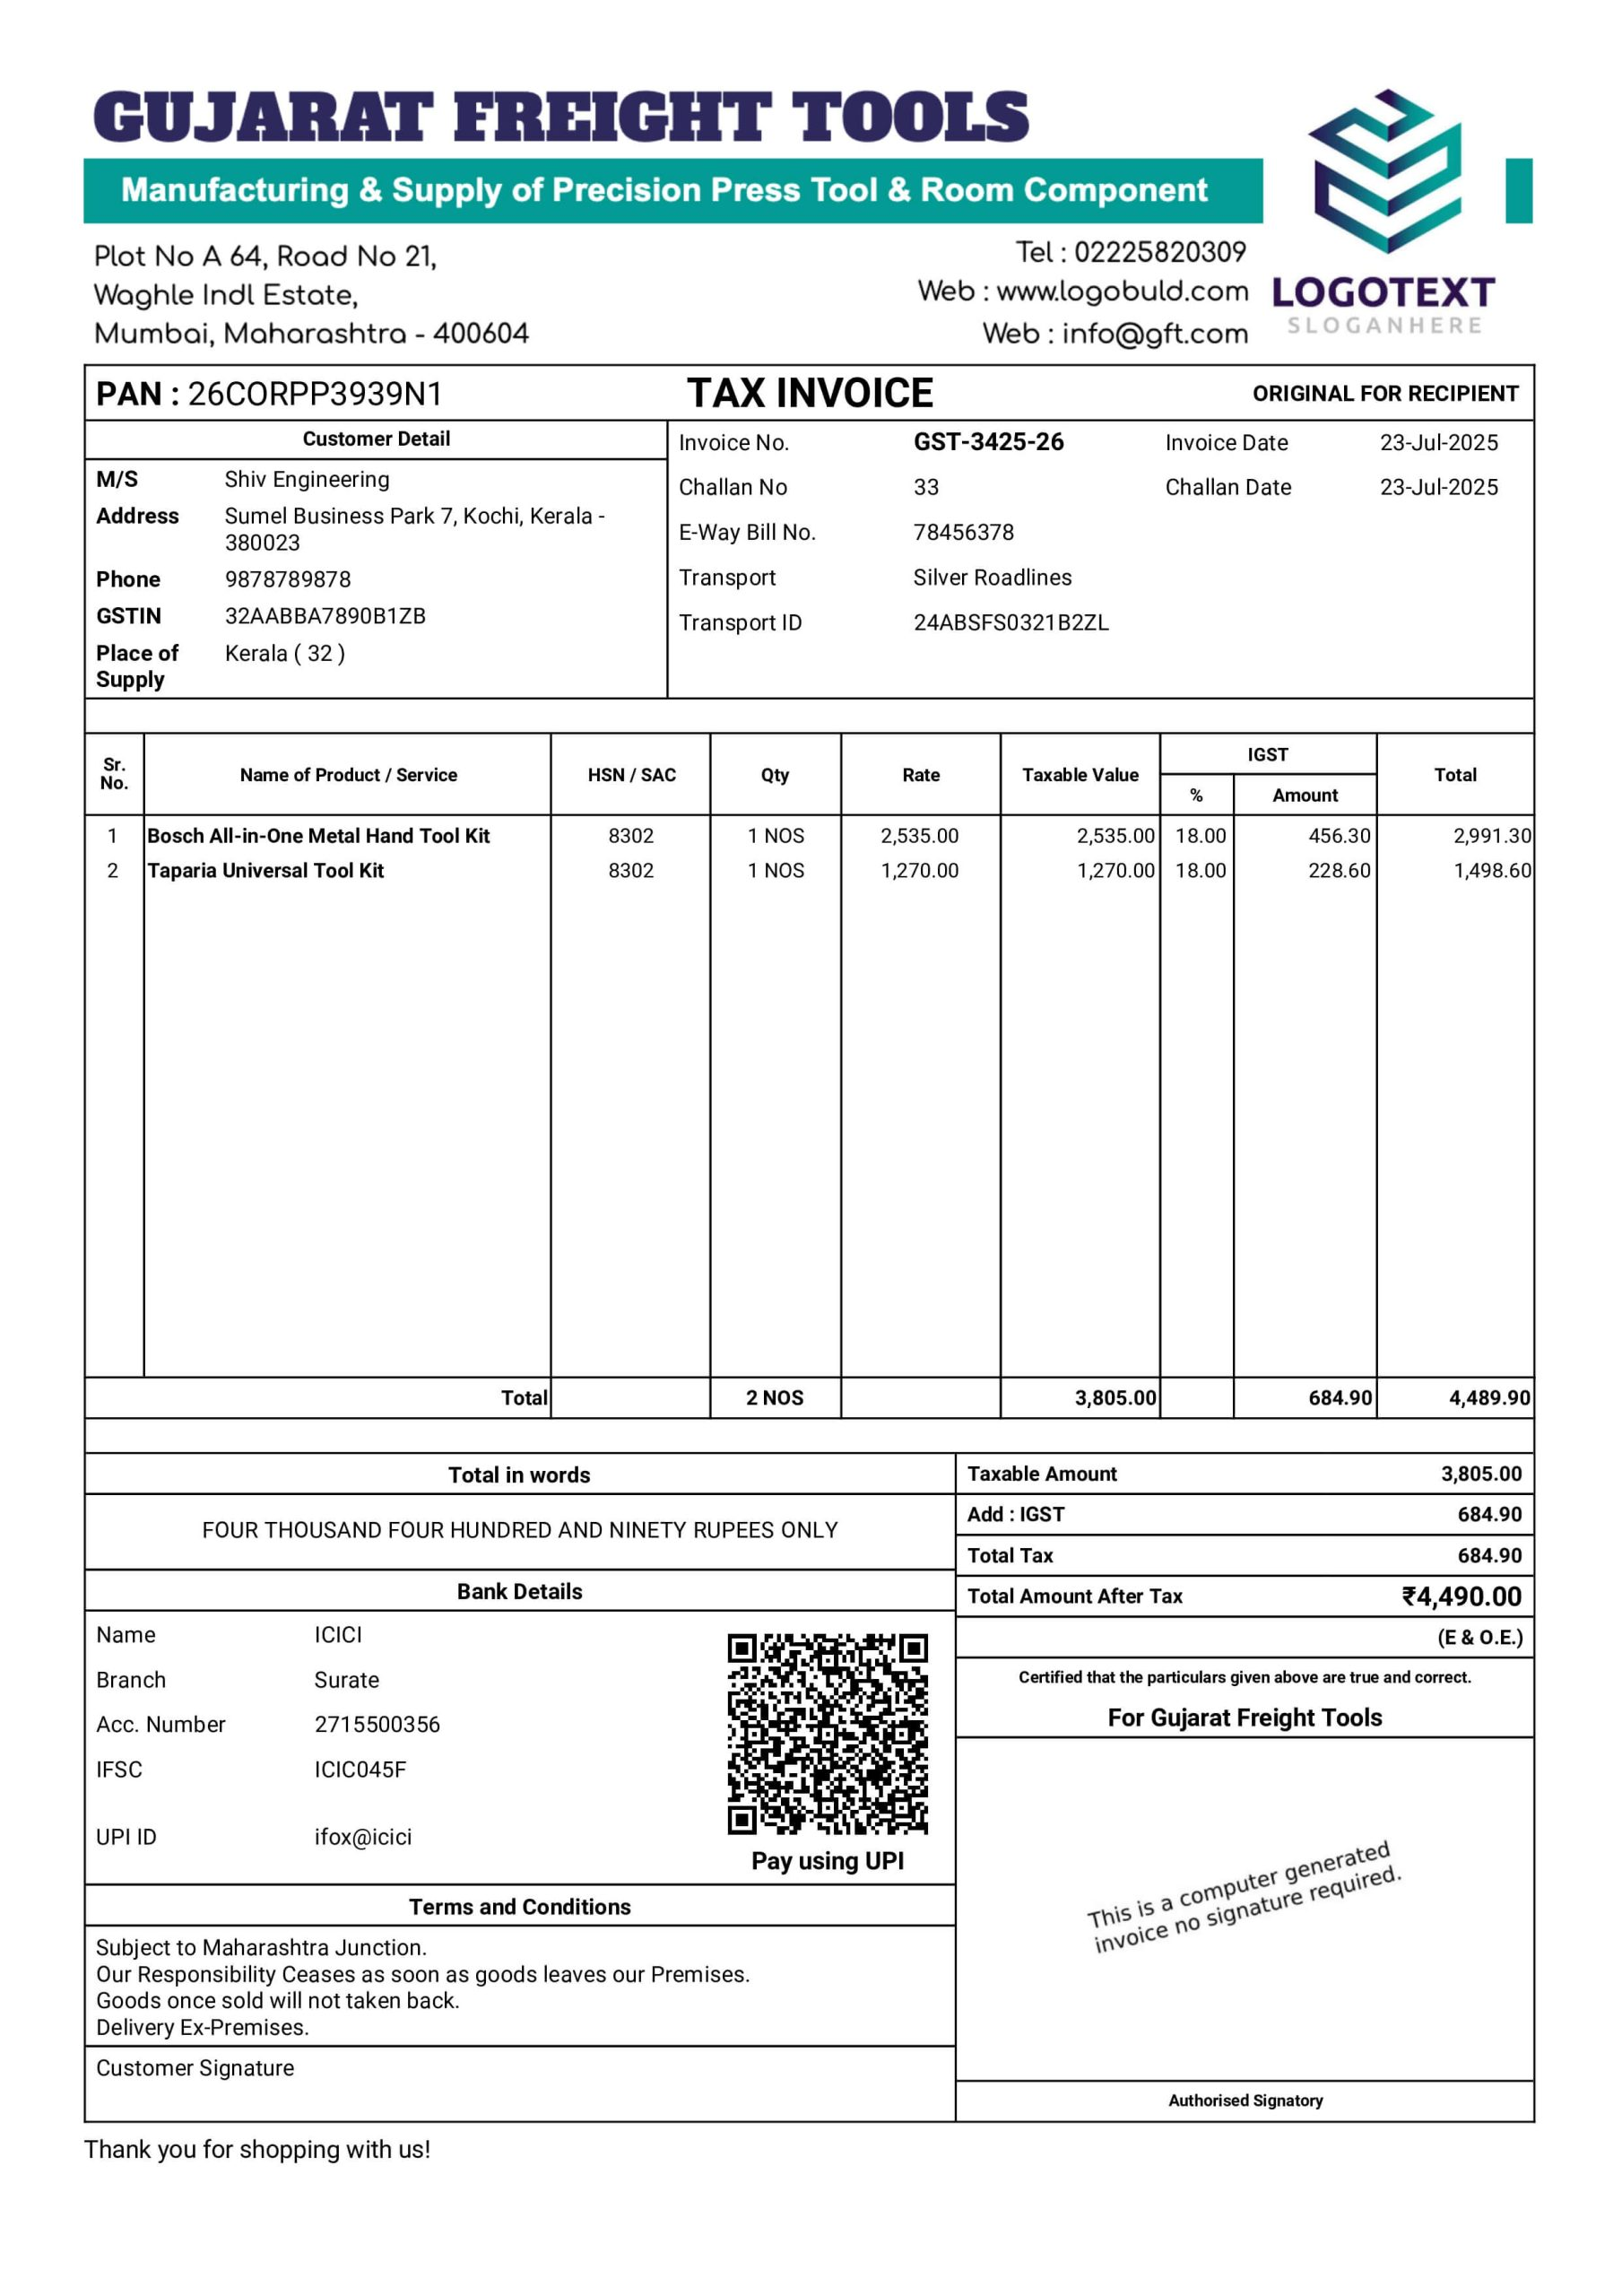

In [ ]:
from PIL import Image

image = Image.open(image_path).convert("RGB")

print("Image size:", image.size)
print("Image mode:", image.mode)

display(image)

In [ ]:
import pytesseract

ocr_text = pytesseract.image_to_string(
    image,
    lang="eng",
    # config="--psm 6"
)

print("Characters:", len(ocr_text))
print("Lines:", len(ocr_text.splitlines()))

print("\n========== OCR RESULT ==========\n")
print(ocr_text)

Characters: 1449
Lines: 59

========== OCR RESULT ==========

GUJARAT FREIGHT TOOLS

Manufacturing & Supply of Precision Press Tool & Room Component |
Plot No A 64, Road No 21, Tel : 02225820309
Waghle Indl Estate, Web : wwwlogobuld.com LOGOTEXT
Mumbai, Maharashtra - 400604 Web : info@gft.com
PAN : 26CORPP3939N1 TAX INVOICE ORIGINAL FOR RECIPIENT

Customer Detail Invoice No. GST-3425-26 Invoice Date 23-Jul-2025

M/S Shiv Engineering Challan No 33 Challan Date 23-Jul-2025

Address Sumel Business Park 7, Kochi, Kerala - |
380023 E-Way Bill No. 78456378

Phone 9878789878 Transport Silver Roadlines

GSTIN 32AABBA7890B1ZB Transport ID 24ABSFS0321B2ZL
Place of Kerala ( 32)
Supply

IGST
Ee ee Tanevens — =
456.30
228.60

Bosch All-in-One Metal Hand Tool Kit 8302 1NOS 2,535.00 2,535.00} 18.00
2. |Taparia Universal Tool Kit 8302 1 NOS 1,270.00 1,270.00] 18.00

Total in words Taxable Amount 3,805.00
Add : IGST

FOUR THOUSAND FOUR HUNDRED AND NINETY RUPEES ONLY
Total Tax 684.90

Bank Details Total

File: image2 (1).jpg
Exists: True
Format: JPEG
Size: (1809, 2560)
Mode: RGB


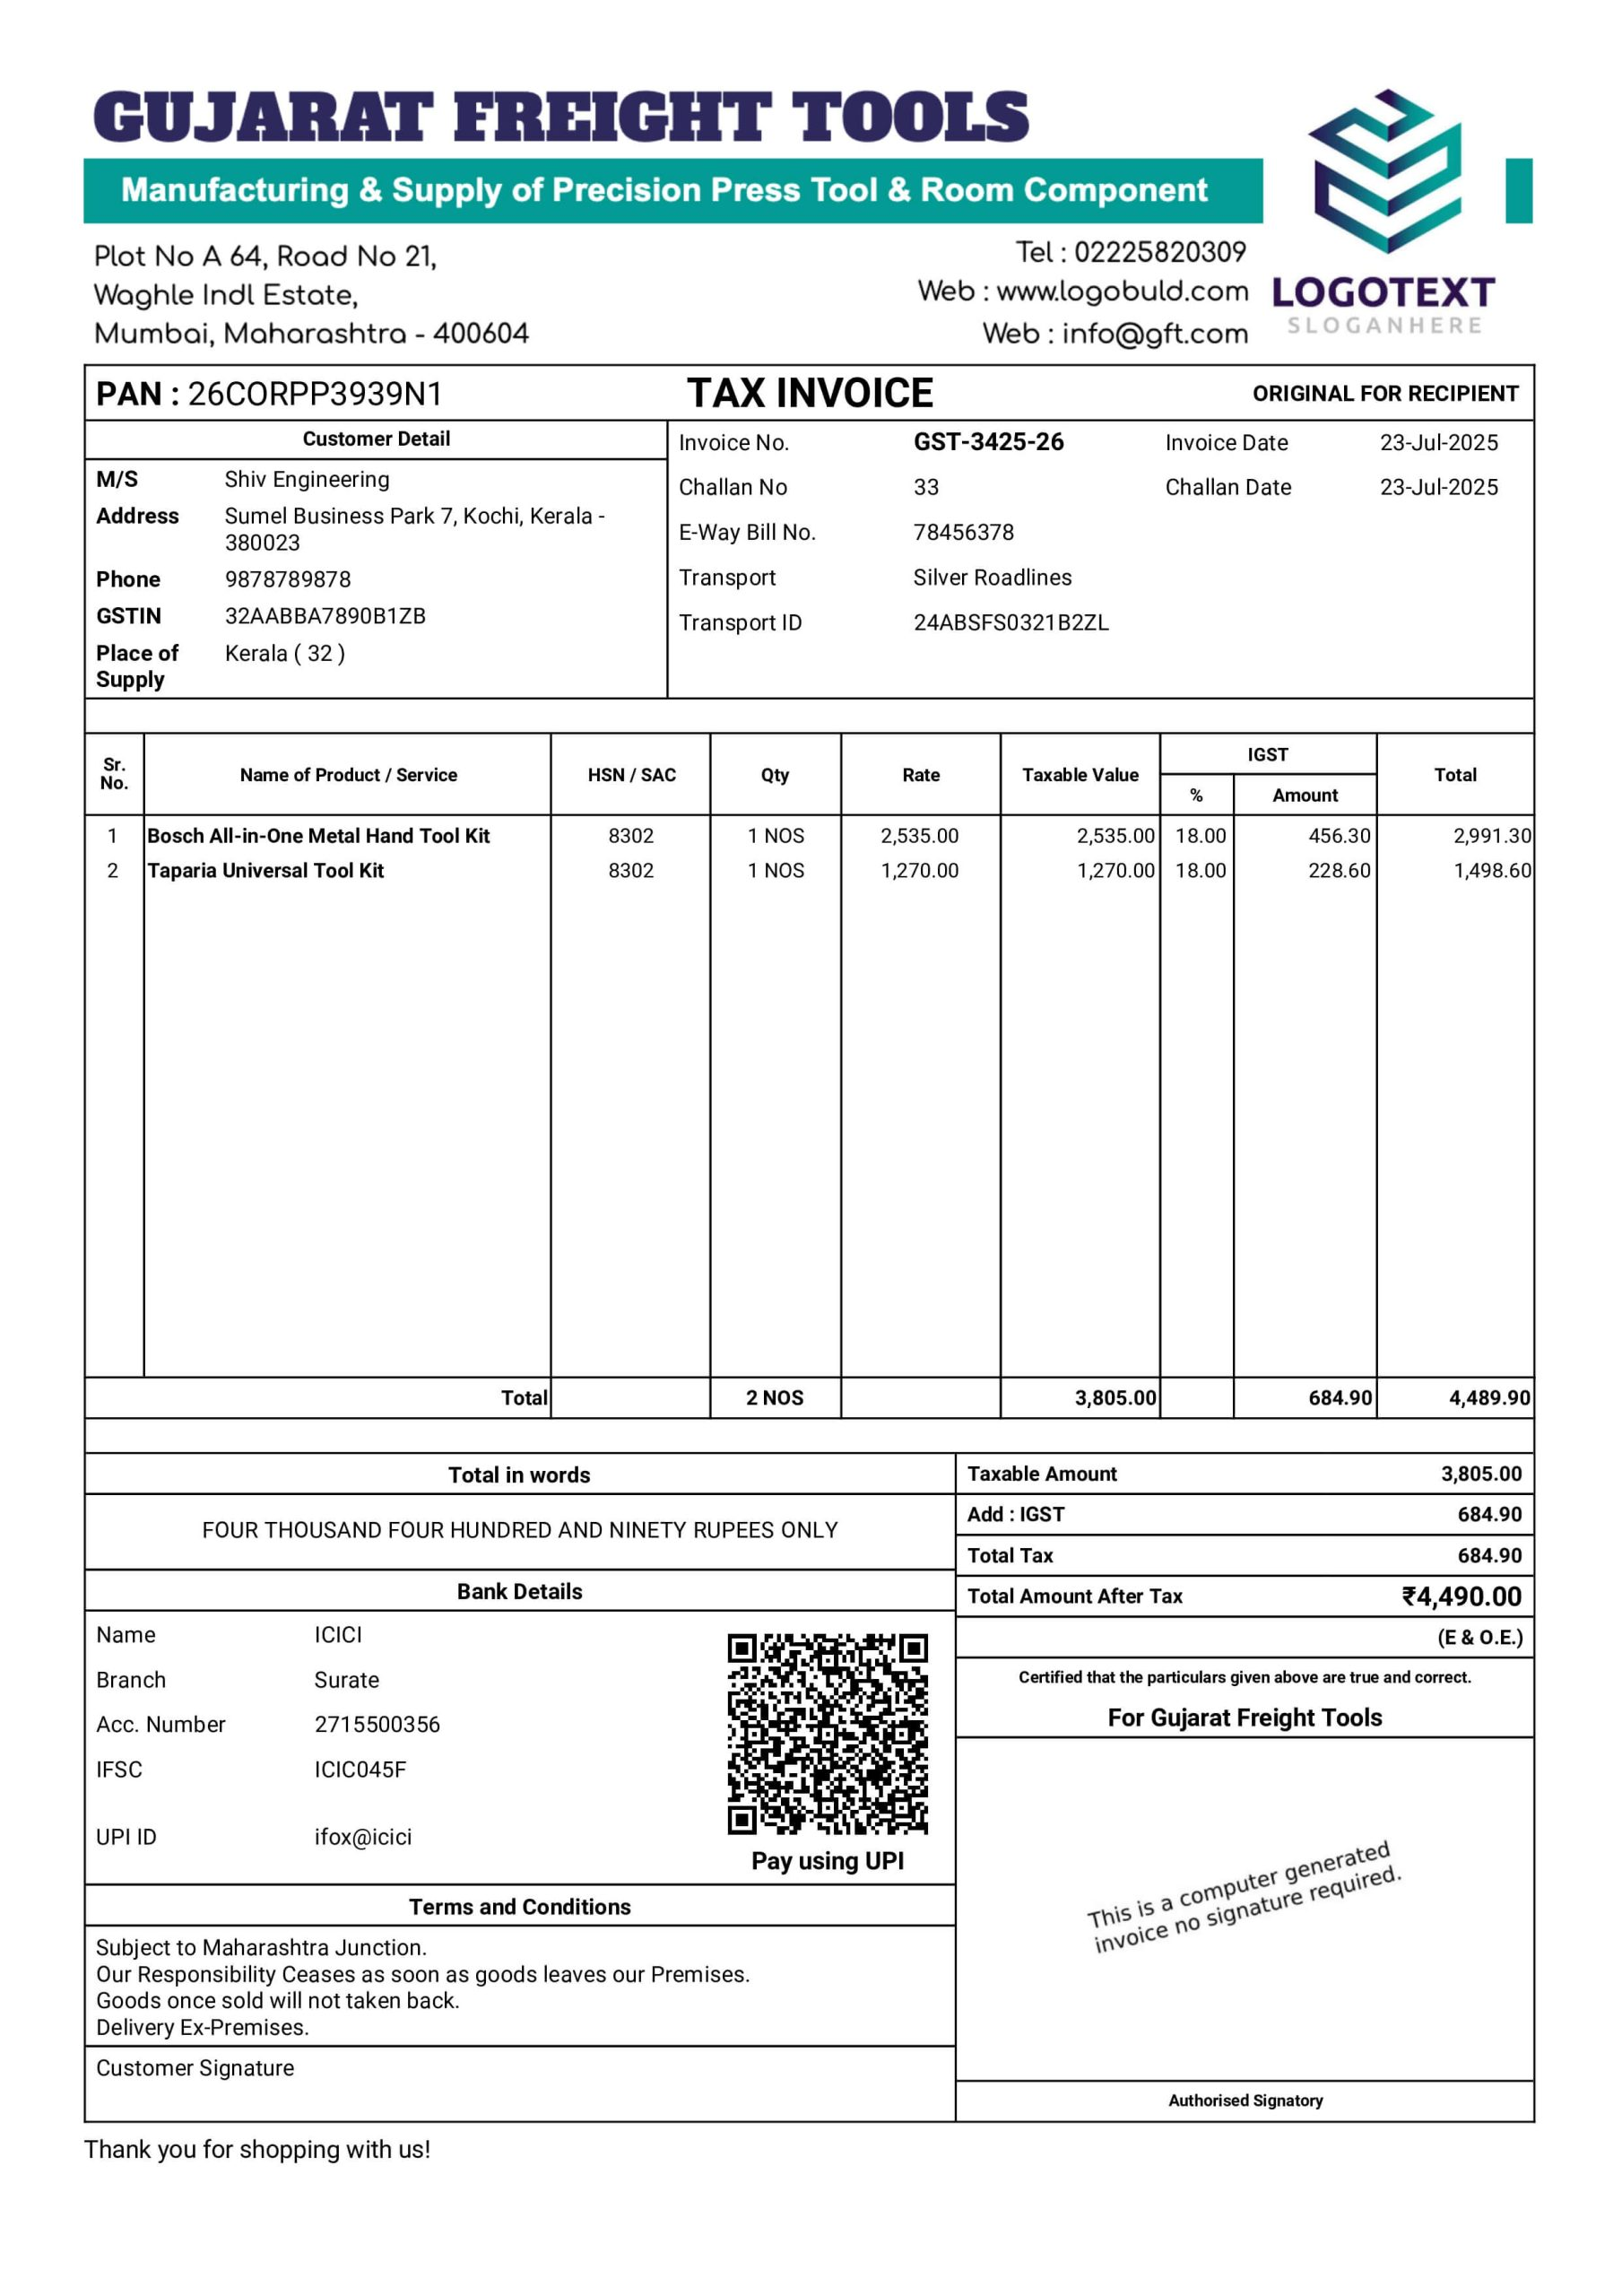

In [ ]:
from PIL import Image
import os

print("File:", image_path)
print("Exists:", os.path.exists(image_path))

image = Image.open(image_path)

print("Format:", image.format)
print("Size:", image.size)
print("Mode:", image.mode)

display(image)

In [ ]:
import pytesseract

print("Testing OCR...")

text = pytesseract.image_to_string(
    image,
    lang="eng",
    config="--psm 6"
)

print("Characters detected:", len(text))
print("Lines detected:", len(text.splitlines()))

print("\n========== OCR RESULT ==========\n")
print(repr(text))
print("\n================================")

Testing OCR...
Characters detected: 1565
Lines detected: 39

========== OCR RESULT ==========

'Manufacturing & Supply of Precision Press Tool & Room Component Y i\nPlot No A 64, Road No 21, Tel : 02225820309\nWaghle Indl Estate, Web : wwwlogobuld.com LOGOTEXT\nMumbai, Maharashtra - 400604 Web : info@gft.com\nPAN : 26CORPP3939N1 TAX INVOICE ORIGINAL FOR RECIPIENT\nihveleeNen GST-3425-26 Invoice Date 23-Jul-2025\nM/S Shiv Engineering Challan No 33 Challan Date 23-Jul-2025\nAddress Sumel Business Park 7, Kochi, Kerala - F\n380023 E-Way Bill No. 78456378\nPhone 9878789878 Transport Silver Roadlines\nGSTIN 32AABBA7890B1ZB Transport ID 24ABSFS0321B2ZL\nPlace of Kerala ( 32)\nSupply\nSE] semetrmanmnn [tvs | oy | mie | tate z= om |\nName of Product / Service HSN / SAC Qty Rate Taxable Value Tx | amount | Total\n1. |Bosch All-in-One Metal Hand Tool Kit 8302 1NOS 2,535.00 2,535.00} 18.00 456.30 2,991.30\n2 |Taparia Universal Tool Kit 8302 1 NOS 1,270.00 1,270.00] 18.00 228.60 1,498.60)\naf anes

In [ ]:
keywords = [
    "invoice",
    "total",
    "tax",
    "subtotal",
    "date"
]

for keyword in keywords:
    if keyword.lower() in ocr_text.lower():
        print(f"{keyword}: FOUND")
    else:
        print(f"{keyword}: NOT FOUND")

invoice: FOUND
total: FOUND
tax: FOUND
subtotal: NOT FOUND
date: FOUND


In [ ]:
ocr_prompt = f"""
You are an invoice understanding assistant.

Below is OCR text extracted from an invoice.

Identify:

- Vendor
- Invoice number
- Invoice date
- Subtotal
- Tax
- Discount
- Total

Do not invent missing information.

OCR TEXT:
{ocr_text}
"""

response = llm.invoke(ocr_prompt)

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the OCR text provided, here are the extracted details:\n\n* **Vendor:** GUJARAT FREIGHT TOOLS\n* **Invoice number:** GST-3425-26\n* **Invoice date:** 23-Jul-2025\n* **Subtotal:** 3,805.00\n* **Tax:** 684.90\n* **Discount:** Not specified\n* **Total:** 4,490.00', 'extras': {'signature': 'EuwMCukMAWkUfRP53gxR1hSfc6RvbSPyoSKuRj76ZJpZrAiE38W6sLU5GXfuqlp9Tr1TBI9Nc3EuO3A0rSwwIYG5FDcsPzax2Esw1f0k9b2qYDokjtfowL441547jDlVX1F7/0wQdWRG4pejmw8JimzJi0cPBqsNlSMO+olvohEes/YOGAtwLzCQ0TWKtqDdPYF37ItSDmCbauER9KuauSm6cfVOVofFRIbH/tbOLuL/C/9J+rFQoKe11l8/RU9yWp764KrMmwS0K+KSvxqHxrxeLoh7qEJ4hn4+Ed0Zk54k2vI/qEZSgXu2Gcw5y2MeSsSI9gwV3Fx/sd0BhnkeAqJzKczIPrTjQIZW13SOSEPkCtLVZQZAFtcpK3k6kx8xAAxogLcaKYOEgdwbeV412qcsBE2yeaS0GKMRdgvX1zCxxiuK9GvWCdY/uVXir4djy7zAUlGPPHWJpmuzZFK45Eg17yf79QEYFD/9ZTafmCvlDOQq5MD2TUFt3YF8YT0Q/JUoJ5FZcrSo907d1SZc3cvE0HyykEWk/kKDs9OjPjT6k2RPbpHNRxKtpTn203khI8eoV3g4mscBUNFTNJvQjqJirJYvfbnDRESzZccx9MWuXuYeQ/rBVCyDZgYg4+exz2Fv7ruqAsz13bePBjDAR1Z8P5/5myUM5eg4

In [ ]:
def calculate_total(subtotal, tax, discount):
    return subtotal + tax - discount

In [ ]:
result = calculate_total(
    subtotal=1000,
    tax=180,
    discount=50
)

print("Final total:", result)

Final total: 1130


In [ ]:
@tool
def calculate_invoice_total(
    subtotal: float,
    tax: float,
    discount: float = 0
) -> float:
    """Calculate final invoice total."""

    return subtotal + tax - discount

In [ ]:
print("Tool name:", calculate_invoice_total.name)
print("Description:", calculate_invoice_total.description)

Tool name: calculate_invoice_total
Description: Calculate final invoice total.


In [ ]:
result = calculate_invoice_total.invoke({
    "subtotal": 1000,
    "tax": 180,
    "discount": 50
})

print("Tool result:", result)

Tool result: 1130.0


In [ ]:
llm_with_tools = llm.bind_tools(
    [calculate_invoice_total]
)

In [ ]:
response = llm_with_tools.invoke(
    "Calculate an invoice total where subtotal is 5000, tax is 900 and discount is 200."
)

print("Text:")
print(response.content)

print("\nTool calls:")
print(response.tool_calls)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Text:
[]

Tool calls:
[{'name': 'calculate_invoice_total', 'args': {'tax': 900, 'subtotal': 5000, 'discount': 200}, 'id': 'call_282048', 'type': 'tool_call'}]


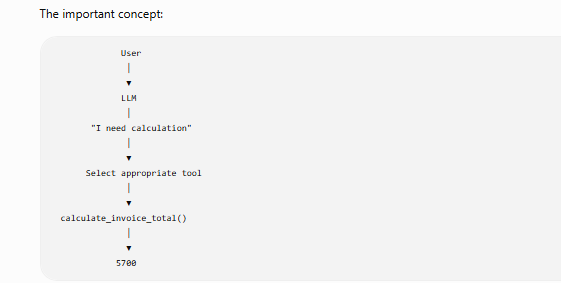

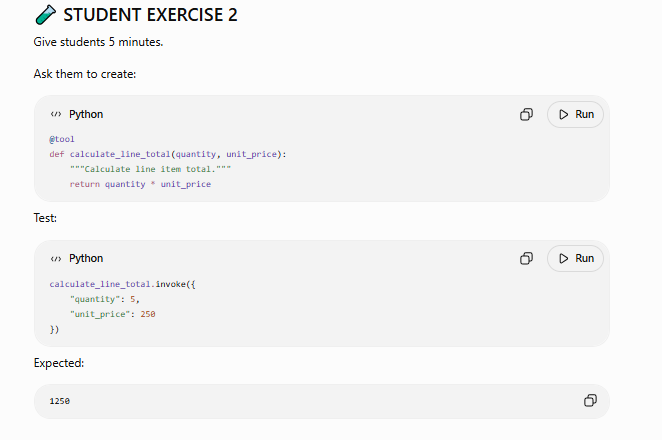

In [ ]:
response = llm.invoke(
    f"""
    Extract the vendor, invoice number,
    subtotal, tax and total from this OCR text.

    OCR:
    {ocr_text}
    """
)

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Here are the extracted details from the OCR text:\n\n* **Vendor:** GUJARAT FREIGHT TOOLS\n* **Invoice Number:** GST-3425-26\n* **Subtotal:** 3,805.00\n* **Tax:** 684.90\n* **Total:** 4,490.00', 'extras': {'signature': 'EssKCsgKAWkUfROI4qcoVG4fI8FYDxIGKN3hIJs68SO9Q90RhPCGCGEUdI6v9/In+plVrsX3T7KYe+lEQ8PNlUX/n8AWHMNLiX2YOvjDOObMnU2QQKDNCHex++s9ThDgfIx5i9nDMi6j+6GtlY44HZK1M9fCcqJmZK9cULIlrExK3O+SdXxJ9HB+MWPnuBhslRKs1JLf2sJjNDt9sIAQte6Vp2LhQ/qYvIpFgHracSBPpKbKhXKsywi5wRbJzg+L0SoTarzl218PHCKxuFLQ3sbohEnNDai+oPDpPdI8a2xscT4t/n8i6OLVjC4JuANO8Js2CrkXgAjl6c6MxuvwqmULKL/6ACKDBXvadzihwe6d/zcXnHnittCQUyzrxQyYi6UjZxvsGcbcn/tKE5CD2A4N5ubTknlytW5wmkTb9A9R6HJMdD5mgBZWTH15Bf8vbBHIAfgH03W0HB8bQMUx1Z7uuW1ZCCLBzRTLe3TwC7jw19HqIf9uWBpJz1+/X+NP7PjK53hVuUqb7d5fO45oCOTbb92PxLSna3YrgD1YCuWSOBsxej7zdwHPkkm2g7/u6IA9QnOl9qgGJvuuClLLh5e29i3akKrvxbaU1M8AvNpb+r5D+F6kbPw3MHS44MVLHfSH+slz6RktPmdgToFHSaGV4MxCzTWmLv2uus18MYqr/G5gHeG39xuRvoMh1FlwDeRsOX3b01UxDsenwJgQQnqlxOBXXTmUHvw5kE3iDYiDm0drYD

In [ ]:
class Invoice(BaseModel):
    vendor: str | None = None
    invoice_number: str | None = None
    invoice_date: str | None = None
    subtotal: float | None = None
    tax: float | None = None
    discount: float = 0
    total: float | None = None

In [ ]:
print(Invoice.model_json_schema())

{'properties': {'vendor': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Vendor'}, 'invoice_number': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Invoice Number'}, 'invoice_date': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Invoice Date'}, 'subtotal': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Subtotal'}, 'tax': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Tax'}, 'discount': {'default': 0, 'title': 'Discount', 'type': 'number'}, 'total': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Total'}}, 'title': 'Invoice', 'type': 'object'}


In [ ]:
structured_llm = llm.with_structured_output(Invoice)

In [ ]:
invoice = structured_llm.invoke(
    f"""
    Extract invoice information from the OCR text below.

    Rules:
    - Do not invent missing information.
    - Return null when information is unavailable.

    OCR:
    {ocr_text}
    """
)

print(invoice)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


vendor='GUJARAT FREIGHT TOOLS' invoice_number='GST-3425-26' invoice_date='23-Jul-2025' subtotal=3805.0 tax=684.9 discount=0.0 total=4490.0


In [ ]:
print("Vendor:", invoice.vendor)
print("Invoice number:", invoice.invoice_number)
print("Subtotal:", invoice.subtotal)
print("Tax:", invoice.tax)
print("Total:", invoice.total)

Vendor: GUJARAT FREIGHT TOOLS
Invoice number: GST-3425-26
Subtotal: 3805.0
Tax: 684.9
Total: 4490.0


In [ ]:
invoice_test = Invoice(
    vendor="ABC Pvt Ltd",
    invoice_number="INV-1001",
    invoice_date="10/09/2026",
    subtotal=1000,
    tax=180,
    discount=50,
    total=1130
)

print(invoice_test)

vendor='ABC Pvt Ltd' invoice_number='INV-1001' invoice_date='10/09/2026' subtotal=1000.0 tax=180.0 discount=50.0 total=1130.0


In [ ]:
try:
    bad_invoice = Invoice(
        vendor="ABC Pvt Ltd",
        subtotal="hello"
    )

    print(bad_invoice)

except Exception as e:
    print("Validation error:")
    print(e)

Validation error:
1 validation error for Invoice
subtotal
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='hello', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/float_parsing


In [ ]:
def validate_invoice(invoice):

    if invoice.subtotal is None:
        return {
            "status": "REVIEW",
            "reason": "Subtotal missing"
        }

    if invoice.tax is None:
        return {
            "status": "REVIEW",
            "reason": "Tax missing"
        }

    calculated_total = (
        invoice.subtotal
        + invoice.tax
        - invoice.discount
    )

    extracted_total = invoice.total

    if extracted_total is None:
        return {
            "status": "REVIEW",
            "reason": "Total missing",
            "calculated_total": calculated_total
        }

    difference = abs(
        calculated_total - extracted_total
    )

    if difference < 0.01:
        status = "PASS"
    else:
        status = "REVIEW"

    return {
        "status": status,
        "extracted_total": extracted_total,
        "calculated_total": calculated_total,
        "difference": difference
    }

In [ ]:
validation_result = validate_invoice(invoice)

print(
    json.dumps(
        validation_result,
        indent=2
    )
)

{
  "status": "REVIEW",
  "extracted_total": 4490.0,
  "calculated_total": 4489.9,
  "difference": 0.1000000000003638
}


In [ ]:
def analyze_invoice(image_path):

    # -------------------------
    # 1. Read image
    # -------------------------
    image = Image.open(image_path)

    # -------------------------
    # 2. OCR
    # -------------------------
    ocr_text = pytesseract.image_to_string(image)

    # -------------------------
    # 3. Structured extraction
    # -------------------------
    invoice = structured_llm.invoke(
        f"""
        Extract the following invoice fields:

        - vendor
        - invoice_number
        - invoice_date
        - subtotal
        - tax
        - discount
        - total

        Rules:
        - Do not invent information.
        - Use null for missing information.

        OCR TEXT:
        {ocr_text}
        """
    )

    # -------------------------
    # 4. Validate
    # -------------------------
    validation = validate_invoice(invoice)

    # -------------------------
    # 5. Final result
    # -------------------------
    result = {
        "invoice": invoice.model_dump(),
        "validation": validation
    }

    return result

In [ ]:
   final_result = analyze_invoice(image_path)

print(
    json.dumps(
        final_result,
        indent=2,
        default=str
    )
)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{
  "invoice": {
    "vendor": "GUJARAT FREIGHT TOOLS",
    "invoice_number": "GST-3425-26",
    "invoice_date": "23-Jul-2025",
    "subtotal": 3805.0,
    "tax": 684.9,
    "discount": 0.0,
    "total": 4490.0
  },
  "validation": {
    "status": "REVIEW",
    "extracted_total": 4490.0,
    "calculated_total": 4489.9,
    "difference": 0.1000000000003638
  }
}


                 ┌───────────────┐
                 │ Invoice Image │
                 └───────┬───────┘
                         │
                         ▼
                  ┌────────────┐
                  │    OCR     │
                  └─────┬──────┘
                        │
                        ▼
                 ┌─────────────┐
                 │    Gemini   │
                 │  Reasoning  │
                 └──────┬──────┘
                        │
                        ▼
               ┌─────────────────┐
               │ Structured      │
               │ Output / JSON   │
               └────────┬────────┘
                        │
                        ▼
                 ┌────────────┐
                 │ Pydantic   │
                 │ Validation │
                 └─────┬──────┘
                       │
                       ▼
              ┌──────────────────┐
              │ Calculation Tool │
              └────────┬─────────┘
                       │
                       ▼
                ┌────────────┐
                │ Validation │
                └─────┬──────┘
                      │
             ┌────────┴────────┐
             ▼                 ▼
          PASS              REVIEW

**Assigment**

Modify the invoice analyzer to also extract customer_name, currency, due_date, and payment_status **

**bold text**